# Idaho Redistricting — MAUP Data Preparation

In [5]:
import pandas as pd
import geopandas as gpd
import maup
from maup import smart_repair
import time
import os

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
maup.progress.enabled = True

## Import and Explore the Data

In [8]:
start_time = time.time()
population_df = gpd.read_file("./data/id_pl2020_b/id_pl2020_p2_b.shp")
end_time = time.time()
print("The time to import sc_pl2020_p2_b.shp is:",
      (end_time-start_time)/60, "mins")

The time to import sc_pl2020_p2_b.shp is: 0.05199110507965088 mins


In [9]:
start_time = time.time()
vap_df= gpd.read_file("./data/id_pl2020_b/id_pl2020_p4_b.shp")
end_time = time.time()
print("The time to import sc_pl2020_p4_b.shp is:",
      (end_time-start_time)/60, "mins")

The time to import sc_pl2020_p4_b.shp is: 0.04883938233057658 mins


In [10]:
start_time = time.time()
vest20_df = gpd.read_file("./data/id_vest_20/id_vest_20.shp")
end_time = time.time()
print("The time to import sc_vest_20.shp is:",
      (end_time-start_time)/60, "mins")


start_time = time.time()
vest18_df = gpd.read_file("./data/id_vest_18/id_vest_18.shp")
end_time = time.time()
print("The time to import sc_vest_18.shp is:",
      (end_time-start_time)/60, "mins")

The time to import sc_vest_20.shp is: 0.0006539503733317058 mins
The time to import sc_vest_18.shp is: 0.0006845871607462565 mins


In [11]:
start_time = time.time()
sen_df = gpd.read_file("./data/id_sld_2021/L03.shp")
end_time = time.time()
print("The time to import state senate districts is:",
      (end_time-start_time)/60, "mins")

The time to import state senate districts is: 0.0003345171610514323 mins


In [12]:
start_time = time.time()
county_df = gpd.read_file("./data/id_pl2020_cnty/id_pl2020_cnty.shp")
end_time = time.time()
print("The time to import county.shp is:",
      (end_time-start_time)/60, "mins")

The time to import county.shp is: 0.00033715168635050453 mins


In [13]:
print(population_df.columns)
print(vap_df.columns)
print(vest20_df.columns)
print(vest18_df.columns)
print(sen_df.columns)
print(county_df.columns)

Index(['GEOID20', 'SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'P0020001',
       'P0020002', 'P0020003', 'P0020004', 'P0020005', 'P0020006', 'P0020007',
       'P0020008', 'P0020009', 'P0020010', 'P0020011', 'P0020012', 'P0020013',
       'P0020014', 'P0020015', 'P0020016', 'P0020017', 'P0020018', 'P0020019',
       'P0020020', 'P0020021', 'P0020022', 'P0020023', 'P0020024', 'P0020025',
       'P0020026', 'P0020027', 'P0020028', 'P0020029', 'P0020030', 'P0020031',
       'P0020032', 'P0020033', 'P0020034', 'P0020035', 'P0020036', 'P0020037',
       'P0020038', 'P0020039', 'P0020040', 'P0020041', 'P0020042', 'P0020043',
       'P0020044', 'P0020045', 'P0020046', 'P0020047', 'P0020048', 'P0020049',
       'P0020050', 'P0020051', 'P0020052', 'P0020053', 'P0020054', 'P0020055',
       'P0020056', 'P0020057', 'P0020058', 'P0020059', 'P0020060', 'P0020061',
       'P0020062', 'P0020063', 'P0020064', 'P0020065', 'P0020066', 'P0020067',
       'P0020068', 'P0020069', 'P0020070', 'P0020071', 'P002

In [14]:
print(sen_df.head())

   ID         AREA DISTRICT  MEMBERS LOCKED  NAME  POPULATION  NH_WHT  AP_BLK  \
0   1  3007.444820        1      1.0   None  None       53610   47911     335   
1   2   165.500488       10      1.0   None  None       53498   42570     672   
2   3    22.118641       11      1.0   None  None       53483   29204     902   
3   4    19.979134       12      1.0   None  None       53363   35154     866   
4   5    31.330648       13      1.0   None  None       53581   37340     796   

   AP_IND  ...  F_18_AP_BL  F_18_AP_IN  F_18_AP_AS  F_18_AP_HW  F_18_AP_OT  \
0    1796  ...    0.004473    0.030776    0.010610    0.002553    0.038271   
1    1672  ...    0.009334    0.029273    0.020467    0.004971    0.092868   
2    2233  ...    0.014054    0.039447    0.017648    0.004818    0.266896   
3    1938  ...    0.011923    0.034818    0.021169    0.006052    0.182329   
4    1999  ...    0.011241    0.036513    0.017965    0.005988    0.158027   

   F_H18_POP  DISTRICT_N      MULTIPLE_F  DI

## Columns for Census Data

In [15]:
district_col_name = "DISTRICT"

# Clean the Data

In [18]:
target = population_df.estimate_utm_crs()
population_df = population_df.to_crs(target)    
vap_df = vap_df.to_crs(target)
sen_df = sen_df.to_crs(target)
vest20_df = vest20_df.to_crs(target)
vest18_df = vest18_df.to_crs(target)
county_df = county_df.to_crs(target)

In [17]:
maup.doctor(population_df)

100%|██████████| 81879/81879 [00:56<00:00, 1451.30it/s]


True

In [19]:
maup.doctor(vap_df)

100%|██████████| 81879/81879 [00:56<00:00, 1453.20it/s]


True

In [20]:
maup.doctor(sen_df)

100%|██████████| 35/35 [00:00<00:00, 126.24it/s]


True

In [21]:
vest20_df = smart_repair(vest20_df)
maup.doctor(vest20_df)

Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 15502/15502 [00:01<00:00, 9774.34it/s] 


Resolving overlaps...
Assigning order 2 pieces...
Assigning order 3 pieces...
Filling gaps...


100%|██████████| 935/935 [00:01<00:00, 632.88it/s]


True

In [22]:
vest18_df = smart_repair(vest18_df)
maup.doctor(vest18_df)

Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 15487/15487 [00:01<00:00, 9177.24it/s] 


Resolving overlaps...
Assigning order 2 pieces...
Assigning order 3 pieces...
Filling gaps...


100%|██████████| 933/933 [00:01<00:00, 635.66it/s]


True

In [23]:
import copy
boundaries = copy.deepcopy(vest20_df)
boundaries["geometry"] = boundaries.geometry.boundary  # get boundaries
neighbors = gpd.sjoin(boundaries, vest20_df, predicate="intersects") # find boundaries that intersect
neighbors = neighbors[neighbors.index != neighbors.index_right] # remove boundaries of a region with itself

# compute shared border length using intersection
borders = list(neighbors.apply(
    lambda row: row.geometry.intersection(boundaries.loc[row.index_right, "geometry"]).length, axis=1
))

borders.sort()
print(borders[:1000])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [24]:
final_df = smart_repair(vest20_df, min_rook_length = 30, nest_within_regions=county_df)

100%|██████████| 44/44 [00:00<00:00, 157.72it/s]


Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.


100%|██████████| 44/44 [00:01<00:00, 42.57it/s]


Identifying overlaps...


100%|██████████| 5592/5592 [00:01<00:00, 4784.12it/s]


Resolving overlaps and filling gaps...


Gaps to simplify in region 6: 100%|██████████| 3/3 [00:00<00:00, 111.33it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 7: 100%|██████████| 1/1 [00:00<00:00, 22.16it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 12: 100%|██████████| 3/3 [00:00<00:00, 51.72it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 17: 100%|██████████| 47/47 [00:01<00:00, 45.68it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 19: 100%|██████████| 1/1 [00:00<00:00, 66.73it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 20: 100%|██████████| 1/1 [00:00<00:00, 37.57it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 25: 100%|██████████| 3/3 [00:00<00:00, 68.69it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 26: 100%|██████████| 5/5 [00:00<00:00, 33.27it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 30: 100%|██████████| 5/5 [

Converting small rook adjacencies to queen...


100%|██████████| 4/4 [00:00<00:00, 2375.03it/s]


In [25]:
final_df = smart_repair(vest18_df, min_rook_length = 30, nest_within_regions=county_df)

100%|██████████| 44/44 [00:00<00:00, 145.18it/s]


Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.


100%|██████████| 44/44 [00:01<00:00, 43.34it/s]


Identifying overlaps...


100%|██████████| 5587/5587 [00:01<00:00, 4788.68it/s]


Resolving overlaps and filling gaps...


Gaps to simplify in region 6: 100%|██████████| 3/3 [00:00<00:00, 108.50it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 7: 100%|██████████| 1/1 [00:00<00:00, 22.04it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 12: 100%|██████████| 3/3 [00:00<00:00, 48.57it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 17: 100%|██████████| 47/47 [00:00<00:00, 47.74it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 19: 100%|██████████| 1/1 [00:00<00:00, 62.40it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 20: 100%|██████████| 1/1 [00:00<00:00, 41.28it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 25: 100%|██████████| 3/3 [00:00<00:00, 64.51it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 26: 100%|██████████| 5/5 [00:00<00:00, 31.97it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 30: 100%|██████████| 6/6 [

Converting small rook adjacencies to queen...


100%|██████████| 4/4 [00:00<00:00, 2014.07it/s]


## NEXT

In [26]:
blocks_to_precincts_assignment = maup.assign(population_df.geometry, final_df.geometry)
vap_blocks_to_precincts_assignment = maup.assign(vap_df.geometry, final_df.geometry)

100%|██████████| 933/933 [00:08<00:00, 107.62it/s]


In [27]:
pop_column_names = ['P0020001', 'P0020002', 'P0020005', 'P0020006', 'P0020007',
                    'P0020008', 'P0020009', 'P0020010', 'P0020011']

vap_column_names = ['P0040001', 'P0040002', 'P0040005', 'P0040006', 'P0040007',
                    'P0040008', 'P0040009', 'P0040010', 'P0040011']

In [28]:
cols_to_drop = ['TOTPOP', 'NH_WHITE', 'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI',
                'NH_OTHER', 'NH_2MORE', 'HISP', 'H_WHITE', 'H_BLACK', 'H_AMIN',
                'H_ASIAN', 'H_NHPI', 'H_OTHER', 'H_2MORE', 'VAP', 'HVAP', 'WVAP',
                'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP', '2MOREVAP']
final_df.drop(columns=[c for c in cols_to_drop if c in final_df.columns], inplace=True)

In [29]:
for name in pop_column_names:
    final_df[name] = population_df[name].groupby(blocks_to_precincts_assignment).sum()
for name in vap_column_names:
    final_df[name] = vap_df[name].groupby(vap_blocks_to_precincts_assignment).sum()

In [30]:
rename_dict = {
    'P0020001': 'TOTPOP', 'P0020002': 'HISP', 'P0020005': 'NH_WHITE',
    'P0020006': 'NH_BLACK', 'P0020007': 'NH_AMIN', 'P0020008': 'NH_ASIAN',
    'P0020009': 'NH_NHPI', 'P0020010': 'NH_OTHER', 'P0020011': 'NH_2MORE',
    'P0040001': 'VAP', 'P0040002': 'HVAP', 'P0040005': 'WVAP',
    'P0040006': 'BVAP', 'P0040007': 'AMINVAP', 'P0040008': 'ASIANVAP',
    'P0040009': 'NHPIVAP', 'P0040010': 'OTHERVAP', 'P0040011': '2MOREVAP'
}
final_df.rename(columns=rename_dict, inplace=True)

In [31]:
print(population_df['P0020001'].sum())
print(final_df['TOTPOP'].sum())
print(vap_df['P0040001'].sum())
print(final_df['VAP'].sum())

1839106
1839106
1376400
1376400


In [32]:
final_df.columns

Index(['STATEFP', 'COUNTYFP', 'VTDST', 'NAME', 'G18GOVRLIT', 'G18GOVDJOR',
       'G18GOVLBOE', 'G18GOVCBAY', 'G18GOVOWRI', 'G18LTGRMCG', 'G18LTGDCOL',
       'G18SOSRDEN', 'G18SOSDHUM', 'G18CONRWOO', 'G18TRERELL', 'G18ATGRWAS',
       'G18ATGDBIS', 'G18SPIRYBA', 'G18SPIDWIL', 'geometry', 'TOTPOP', 'HISP',
       'NH_WHITE', 'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER',
       'NH_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP',
       'NHPIVAP', 'OTHERVAP', '2MOREVAP'],
      dtype='object')

In [33]:
precincts_to_districts_assignment = maup.assign(final_df.geometry, sen_df.geometry)
final_df['SDIST'] = precincts_to_districts_assignment

100%|██████████| 35/35 [00:01<00:00, 27.86it/s]


In [34]:
for precinct_index in range(len(final_df)):
    final_df.at[precinct_index, 'SDIST'] = sen_df.at[int(final_df.at[precinct_index, 'SDIST']), district_col_name]
print(set(final_df['SDIST']))

{'20', '14', '31', '7', '32', '21', '34', '29', '15', '19', '28', '35', '33', '25', '6', '12', '22', '26', '27', '3', '18', '8', '24', '9', '10', '11', '30', '17', '2', '16', '13', '1', '4', '23', '5'}


<Axes: >

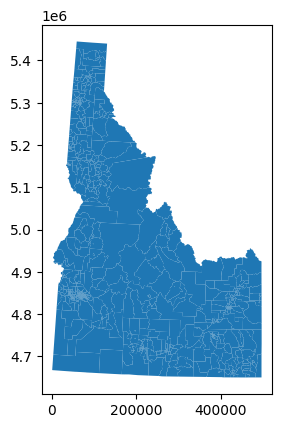

In [35]:
final_df.plot()

## Save the Shapefile

In [36]:
directory = './ID'
if not os.path.exists(directory):
    os.makedirs(directory)
final_df.to_file('./ID/ID.shp')

## Gerrychain

In [37]:
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial

In [38]:
id_graph = Graph.from_file('./ID/ID.shp')

In [40]:
total_steps_in_run = 5000

elections = [
    Election('PRES20', {'Democratic': 'G20PREDBID', 'Republican': 'G20PRERTRU'}),
    Election('GOV18',{'Democratic': 'G18GOVDJOR', 'Republican': 'G18GOVRLIT'}),
]

my_updaters = {
    'population': updaters.Tally('TOTPOP', alias='population'),
    'cut_edges': cut_edges,
    'VAP': updaters.Tally('VAP', alias='VAP'),
}

election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

initial_partition = Partition(
    id_graph,
    assignment='SDIST',
    updaters=my_updaters
)

ideal_population = sum(initial_partition['population'].values()) / len(initial_partition)

proposal = partial(recom,                                                                                    
                    pop_col="TOTPOP",                                                                         
                    pop_target=ideal_population,                                                              
                    epsilon=0.5,                                                                           
                    node_repeats=2                                                                            
                )

compactness_bound = constraints.UpperBound(
    lambda p: len(p['cut_edges']),
    2 * len(initial_partition['cut_edges'])
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.5)

chain = MarkovChain(
    proposal=proposal,
    constraints=[pop_constraint, compactness_bound],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
)

cut_edges_data = []
dem_wins_data = []
eg_data = []

for partition in chain.with_progress_bar():
    cut_edges_data.append(len(partition['cut_edges']))
    dem_wins_data.append(partition['PRES20'].wins('Democratic'))
    eg_data.append(partition['PRES20'].efficiency_gap()) 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cut_edges_data, bins=20)
axes[0].set_title('Cut Edges')
axes[0].set_xlabel('Number of Cut Edges')
axes[0].set_ylabel('Frequency')

axes[1].hist(dem_wins_data, bins=20)
axes[1].set_title('Democratic Wins (PRES20)')
axes[1].set_xlabel('Number of Districts')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('id_histograms.png')
plt.show()

  0%|          | 0/5000 [00:00<?, ?it/s]


KeyError: 'G20PREDBID'

In [50]:
end_time = time.time()
print('The time of execution of above program is :',
      (end_time-start_time)/60, 'mins')

The time of execution of above program is : 32.147527412573496 mins
